# Tilt angle calibration following Bramati et al. (2024)

Horizontal flights for calibration @scirocco:/indian/UAS_project_data/2025_11_03_Arluno/MAVIC/FlightRecords:
* DJIFlightRecord_2025-11-03_[10-45-24].txt
* DJIFlightRecord_2025-11-03_[11-08-09].txt
* DJIFlightRecord_2025-11-03_[10-56-31].txt

,C.wspd,C.wdir
Time (UTC),,
2025-11-03 09:28:55,1.0375,258.75
2025-11-03 09:28:56,1.1460,254.80
2025-11-03 09:28:57,1.3120,245.00
2025-11-03 09:28:58,1.5680,245.00
2025-11-03 09:28:59,1.5900,242.20
...,...,...
2025-11-03 10:20:41,0.6360,241.40
2025-11-03 10:20:42,0.4220,236.00
2025-11-03 10:20:43,0.2900,279.20


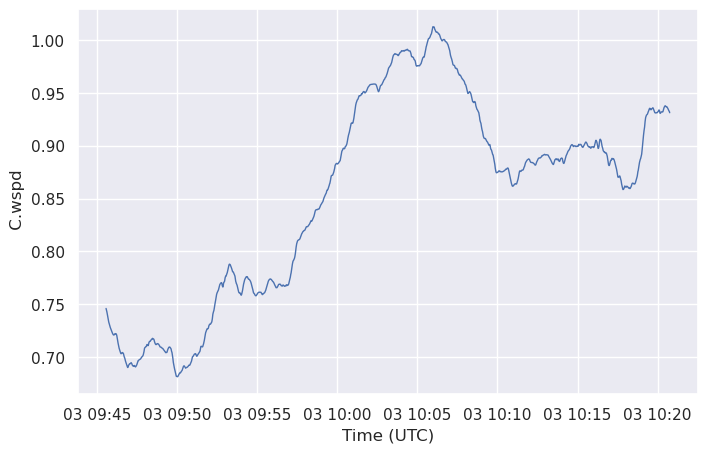

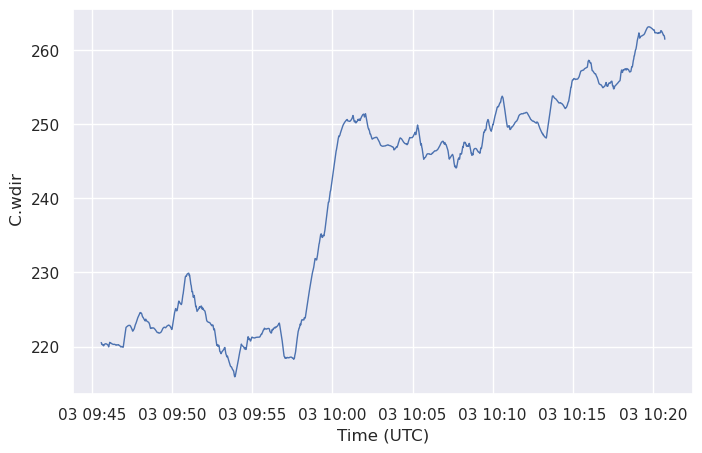

In [193]:
## Trisonica for ref wind speed
import pandas as pd
import numpy as np
tris_df = pd.read_csv('/indian/UAS_project_data/2025_11_03_Arluno/trisonica/20251103_092855_1.csv',sep=';',header=8)
vars_to_keep = np.array(['Time (UTC)',' C.wspd',' C.wdir'])
tris_df = tris_df[vars_to_keep]
tris_df['Time (UTC)'] = [ np.datetime64('2025-11-03T'+time,'s') for time in tris_df['Time (UTC)']]
tris_df = tris_df.groupby(by='Time (UTC)').mean()

import seaborn as sns
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8,5))
sns.lineplot(
    data=tris_df.rolling(window=1000).mean(),
    x='Time (UTC)',
    y=' C.wspd',
    linestyle='solid',
    linewidth=1,
    ax=ax,
)

fig,ax=plt.subplots(figsize=(8,5))
sns.lineplot(
    data=tris_df.rolling(window=1000).mean(),
    x='Time (UTC)',
    y=' C.wdir',
    linestyle='solid',
    linewidth=1,
    ax=ax,
)

tris_df

## Trisonica for ref wind speed

In [194]:
import pandas as pd
import numpy as np
tris_df = pd.read_csv('/indian/UAS_project_data/2025_11_03_Arluno/trisonica/20251103_092855_1.csv',sep=';',header=8)
vars_to_keep = np.array(['Time (UTC)',' C.wspd',' C.wdir'])
tris_df = tris_df[vars_to_keep]
tris_df['Time (UTC)'] = [ np.datetime64('2025-11-03T'+time,'s') for time in tris_df['Time (UTC)']]
tris_df.groupby(by='Time (UTC)').mean()

,C.wspd,C.wdir
Time (UTC),,
2025-11-03 09:28:55,1.0375,258.75
2025-11-03 09:28:56,1.1460,254.80
2025-11-03 09:28:57,1.3120,245.00
2025-11-03 09:28:58,1.5680,245.00
2025-11-03 09:28:59,1.5900,242.20
...,...,...
2025-11-03 10:20:41,0.6360,241.40
2025-11-03 10:20:42,0.4220,236.00
2025-11-03 10:20:43,0.2900,279.20


Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.
3 3267
6 1484
8 988
10 645
12 419


/tmp/ipykernel_69091/1097531550.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'forward' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  fr_df.loc[


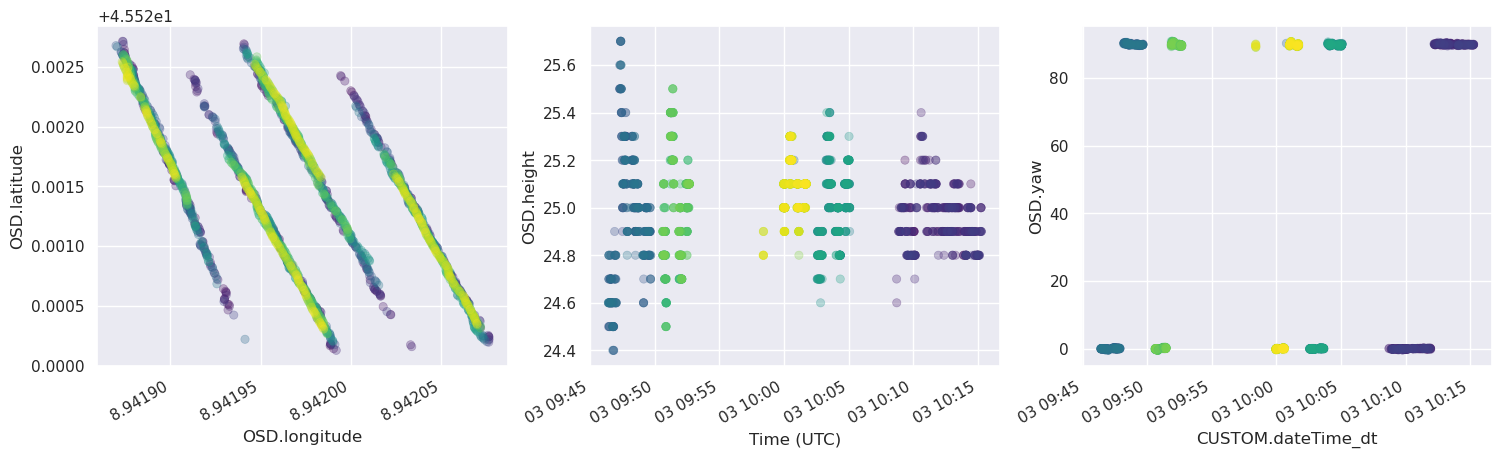

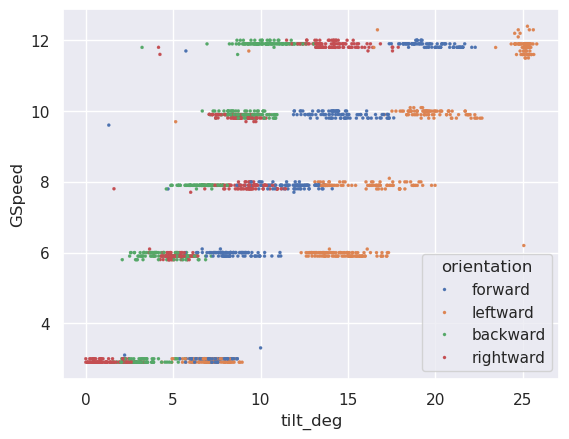

,OSD.latitude,OSD.longitude,OSD.height,OSD.altitude,OSD.xSpeed,OSD.ySpeed,OSD.zSpeed,OSD.pitch,OSD.roll,OSD.yaw,CUSTOM.dateTime_dt,OSD.roll_rad,OSD.pitch_rad,tilt_rad,tilt_deg,GSpeed,GSpeed_mean,GSpeed_rel_a,orientation
0,45.522166,8.941960,24.8,109.905655,2.9,0.0,0.0,-7.1,1.9,-0.1,2025-11-03 10:09:56.980000+00:00,0.033161,-0.123918,0.128268,7.349229,2.900000,2.954525,0.018455,forward
1,45.521186,8.941914,24.9,110.005660,2.9,0.0,0.0,-2.1,-7.7,90.0,2025-11-03 10:12:39.758000+00:00,-0.134390,-0.036652,0.139287,7.980553,2.900000,2.933000,0.011251,leftward
2,45.520630,8.941975,25.0,110.105660,-3.0,0.0,0.0,1.8,1.1,-0.1,2025-11-03 10:11:37.910000+00:00,0.019199,0.031416,0.036816,2.109409,3.000000,2.928068,0.024566,backward
3,45.522314,8.941952,24.9,110.005660,2.9,0.0,0.0,-7.6,3.0,-0.1,2025-11-03 10:10:02.491000+00:00,0.052360,-0.132645,0.142568,8.168556,2.900000,2.921443,0.007340,forward
4,45.522645,8.941875,25.0,110.105660,2.9,0.0,0.0,-0.6,-5.5,90.1,2025-11-03 10:13:33.816000+00:00,-0.095993,-0.010472,0.096564,5.532690,2.900000,2.959034,0.019951,leftward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,45.520759,8.941970,25.2,111.248600,-11.9,0.3,0.0,10.3,0.5,0.0,2025-11-03 10:00:32.486000+00:00,0.008727,0.179769,0.180040,10.315545,11.903781,11.914357,0.000888,backward
1996,45.520470,8.942066,25.1,111.148590,-11.8,0.3,0.0,-1.5,14.0,89.7,2025-11-03 10:01:42.064000+00:00,0.244346,-0.026180,0.246006,14.095130,11.803813,11.880763,0.006477,rightward
1997,45.520306,8.941985,25.3,111.348590,-11.6,0.2,0.0,-8.5,1.8,-0.3,2025-11-03 10:00:36.716000+00:00,0.031416,-0.148353,0.151645,8.688640,11.601724,11.914747,0.026272,backward
1998,45.521072,8.941957,25.3,111.348590,-11.9,0.3,0.1,10.9,2.2,0.2,2025-11-03 10:00:29.631000+00:00,0.038397,0.190241,0.194121,11.122322,11.903781,11.878347,0.002141,backward


In [195]:
import os
import sys
sys.path.append('./..')
from src.preprocess import PreprocessFlightRecord,PlotFlightRecord
from src.tilt_angle import AddTiltAngle,AddGroundSpeed
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2


flights_dict = {
    'DJIFlightRecord_2025-11-03_[10-45-24].csv' : {
        'itime_int' : [500,4450], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[10-56-31].csv' : {
        'itime_int' : [200,5200], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[11-08-09].csv' : {
        'itime_int' : [200,4700], # Interval of indices to consider 
    },
    }


files = np.array(sorted(glob.glob(f"/indian/UAS_project_data/2025_11_03_Arluno/MAVIC/FlightRecords/*")))
files = files[[ True if os.path.basename(file) in flights_dict.keys() else False for file in files ]]

fr_df_ar = []
for file in files:
    flight_dict = flights_dict[os.path.basename(file)]
    fr_df = PreprocessFlightRecord(file,itime_int=flight_dict['itime_int'])
    fr_df = AddTiltAngle(fr_df)
    fr_df = AddGroundSpeed(fr_df)
    fr_df_ar.append(fr_df)

fr_df = pd.concat(fr_df_ar)

fr_df.sort_values(by='CUSTOM.dateTime_dt',inplace=True)

# Keep legs only
fr_df = fr_df.loc[((fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)) | ((fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)) ]
fr_df.reset_index(inplace=True,drop=True)

window=100
fr_df['GSpeed_mean'] = fr_df['GSpeed'].rolling(window=window).mean()
fr_df['GSpeed_rel_a'] = np.abs(fr_df['GSpeed_mean']-fr_df['GSpeed'])/fr_df['GSpeed_mean'] 
fr_df = fr_df.loc[(fr_df['GSpeed_rel_a']< 0.03)].reset_index(drop=True)

# Save info on orientation
orientations_dict = {
    'forward' : {'OSD.yaw' : [-1,1],'OSD.xSpeed' : [0,np.inf]},
    'backward' : {'OSD.yaw' : [-1,1],'OSD.xSpeed' : [-np.inf,0]},
    'leftward' : {'OSD.yaw' : [89,91],'OSD.xSpeed' : [0,np.inf]},
    'rightward' : {'OSD.yaw' : [89,91],'OSD.xSpeed' : [-np.inf,0]},
}

fr_df['orientation'] = np.zeros_like(fr_df['GSpeed'])
for orientation in orientations_dict.keys():
    xSpeed_bnd = orientations_dict[orientation]['OSD.xSpeed']
    yaw_bnd = orientations_dict[orientation]['OSD.yaw']
    fr_df.loc[
        (fr_df['OSD.xSpeed']>xSpeed_bnd[0]) & 
        (fr_df['OSD.xSpeed']<xSpeed_bnd[1]) & 
        (fr_df['OSD.yaw']>yaw_bnd[0]) & 
        (fr_df['OSD.yaw']<yaw_bnd[1]),'orientation'] = orientation

# Sample a fixed number of points per GSpeed
GSpeed_values = [3,6,8,10,12]#,15]
gs_df_ar = []
for GSpeed_value in GSpeed_values:
    gs_df = fr_df.loc[(fr_df['GSpeed'] > GSpeed_value-0.5) & (fr_df['GSpeed'] < GSpeed_value+0.5)]
    print(GSpeed_value,len(gs_df))
    gs_df_ar.append(gs_df.sample(n=400))    

fr_df = pd.concat(gs_df_ar).reset_index(drop=True)

PlotFlightRecord(fr_df)
plt.show()

import seaborn as sns
"""
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']>0) & (fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='red',
    edgecolor=None,
    s=5,
    alpha=0.5,
    label='leftward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']>0) & (fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='orange',
    edgecolor=None,
    s=5,
    alpha=0.5,    
    label='forward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']<0) & (fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='blue',
    edgecolor=None,
    s=5,
    alpha=0.5,
    label='rightward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']<0) & (fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)],
    x='CUSTOM.dateTime_dt',
    y='GSpeed',
    color='green',
    edgecolor=None,
    s=5,
    alpha=0.5,    
    label='backward',
)
plt.show()

sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']>0) & (fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)],
    x='tilt_deg',
    y='GSpeed',
    color='red',
    edgecolor=None,
    s=5,
    alpha=0.5,
    label='leftward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']>0) & (fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)],
    x='tilt_deg',
    y='GSpeed',
    color='orange',
    edgecolor=None,
    s=5,
    alpha=0.5,    
    label='forward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']<0) & (fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)],
    x='tilt_deg',
    y='GSpeed',
    color='blue',
    edgecolor=None,
    s=5,
    alpha=0.5,
    label='rightward',
)
sns.scatterplot(
    data=fr_df.loc[(fr_df['OSD.xSpeed']<0) & (fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)],
    x='tilt_deg',
    y='GSpeed',
    color='green',
    edgecolor=None,
    s=5,
    alpha=0.5,    
    label='backward',
)
"""
sns.scatterplot(
    data=fr_df,
    x='tilt_deg',
    y='GSpeed',
    hue='orientation',
    edgecolor=None,
    s=5,
    #alpha=0.5,    
    )


plt.show()

fr_df

## Direct method

c3 : 141.9906728488054,c2 : -143.85346977969738,c1 : 58.8798621988773,c0 : 1.431618361220366


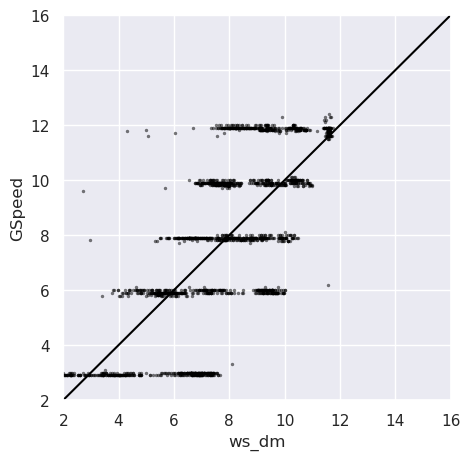

In [196]:
import numpy as np
c3,c2,c1,c0 = np.polyfit(x=fr_df['tilt_rad'],y=fr_df['GSpeed'],deg=3)

# Compute wind speed from Direct Model (polyfit)
fr_df['ws_dm'] = c3 * fr_df['tilt_rad']**3 + c2* fr_df['tilt_rad']**2 + c1 * fr_df['tilt_rad'] + c0

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.scatterplot(
    data=fr_df,
    x='ws_dm',
    y='GSpeed',
    color='black',
    edgecolor=None,
    s=5,
    alpha=0.5,    
)

plt.plot(np.arange(0,17,1),color='black')
plt.xlim((2,16))
plt.ylim((2,16))
print(f"c3 : {c3},c2 : {c2},c1 : {c1},c0 : {c0}")

## $C_A$ method (single direction)

See /home/lorenzo/Documents/HErZ_SummerSchool/uas-analysis/uas-data/scripts/wind-calib.py

/tmp/ipykernel_69091/2438870211.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_means = fr_df[['CA','GSpeed','GSpeed_class','tilt_deg']].groupby('GSpeed_class').mean()
/home/lorenzo/miniconda3/envs/ph_SST_W/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Fitted parameters: c0 = 0.12527175371572968, c1 = 2.3567418906574615, c2 = 3.130433094973338
c2 : 3.130433094973338,c1 : 2.3567418906574615,c0 : 0.12527175371572968


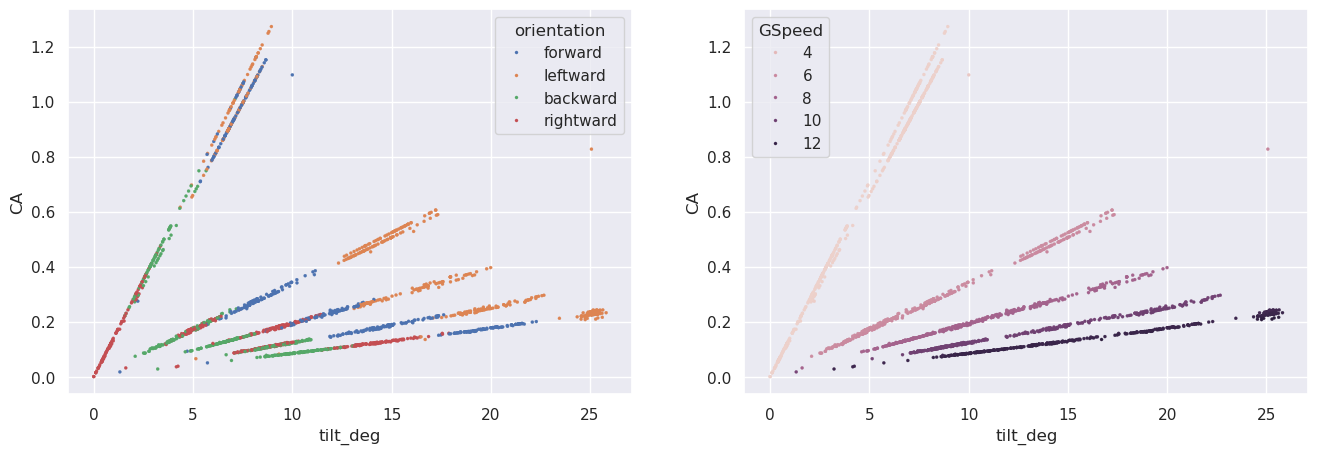

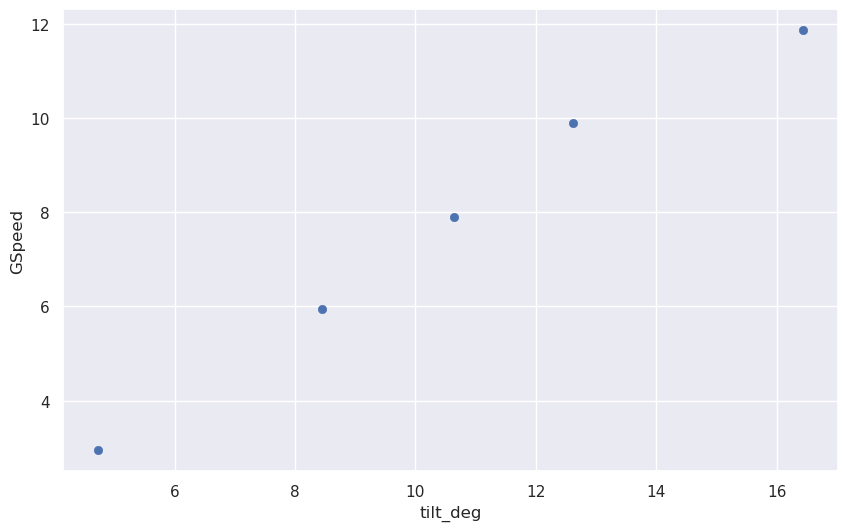

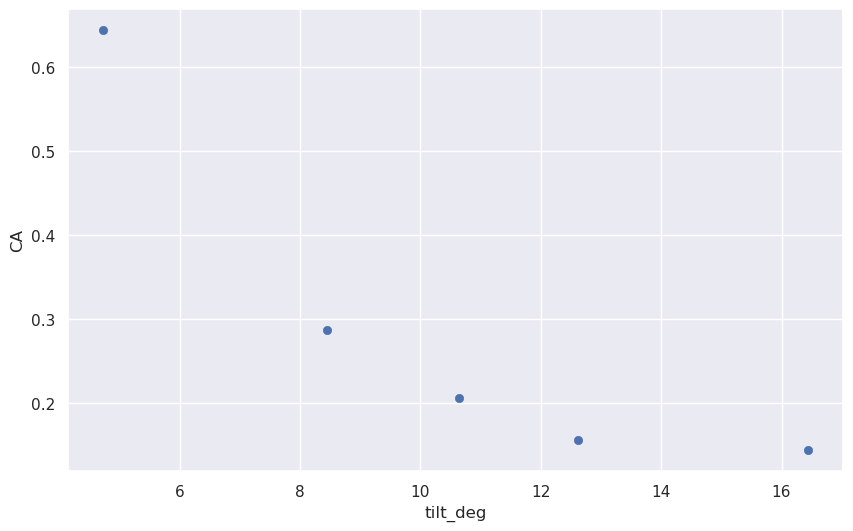

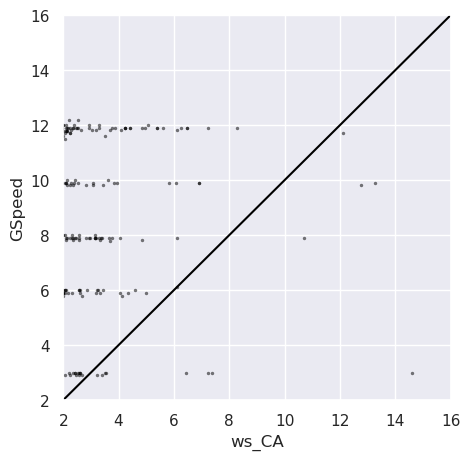

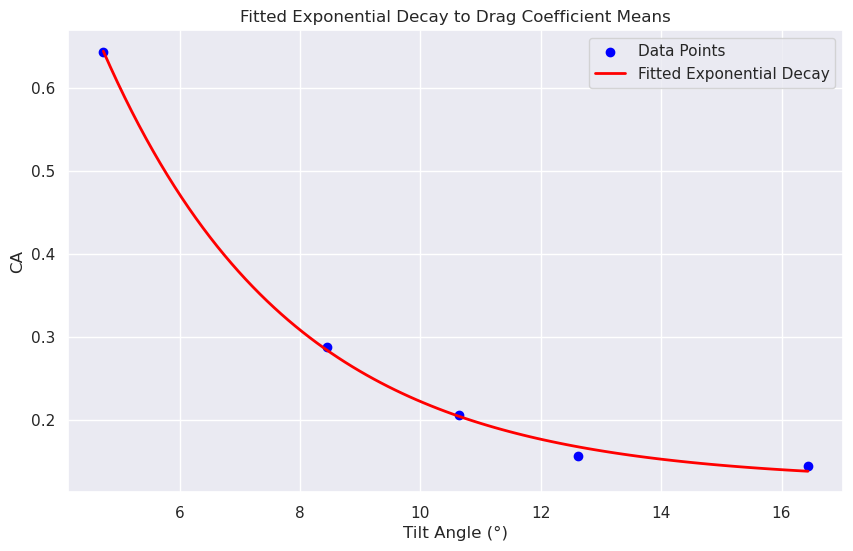

In [197]:
# Select direction
#fr_df = fr_df.loc[(fr_df['orientation'] == 'forward') | (fr_df['orientation'] == 'backward')]
#fr_df = fr_df.loc[(fr_df['orientation'] == 'leftward') | (fr_df['orientation'] == 'rightward')]

def calculate_CA(df, mass, dimension, air_density):
    # Parameters
    g = 9.81  # Gravity in m/s^2
    r = dimension / 100  # Convert dimension from cm to meters
    A_0 = np.pi * np.power(r, 2)  # Reference area

    # Extract necessary columns
    tilt_angle = df['tilt_deg']
    groundspeed = df['GSpeed']

    # Calculate the k_coefficient
    k_coefficient = (air_density * A_0) / (2 * mass * g)

    # Calculate the drag coefficient Ca
    Ca = np.tan(np.radians(tilt_angle)) / (k_coefficient * np.power(groundspeed, 2))
    return Ca

# Example parameters, from Juelich I believe they refer to Mavic3 (Flik)
mass = 1.2  # mass of the drone in kg
dimension = 30  # rotor radius or characteristic dimension in cm
air_density = 1.225  # air density in kg/m^3 (standard at sea level)

# Calculate drag coefficient and add to DataFrame
# According to Eq. 33 of Bramati you compute and then take the mean CA
fr_df['CA'] = np.nan
for orientation in orientations_dict:
    fr_df.loc[fr_df['orientation'] == orientation,'CA'] = calculate_CA(fr_df.loc[fr_df['orientation'] == orientation], mass, dimension, air_density)

# Drop rows where Ca > 5
#fr_df = fr_df[fr_df['CA'] <= 5]

fig,axes=plt.subplots(1,2,figsize=(16,5))
sns.scatterplot(
    data=fr_df,
    x='tilt_deg',
    y='CA',
    hue='orientation',
    edgecolor=None,
    s=5,
    ax=axes[0],
    )

sns.scatterplot(
    data=fr_df,
    x='tilt_deg',
    y='CA',
    hue='GSpeed',
    edgecolor=None,
    s=5,
    ax=axes[1],
    )


import scipy.stats as stats

# Define the speed bins with edges at 1 m/s below and above each target speed
bins = GSpeed_values-0.5*np.ones_like(GSpeed_values)
bins = np.concatenate((bins,[GSpeed_values[-1]+0.5]))
labels = [ f"{GSpeed_value} m/s" for GSpeed_value in GSpeed_values]  # Corresponding labels

# Create a new column in the filtered data for the speed classes
fr_df['GSpeed_class'] = pd.cut(fr_df['GSpeed'], bins=bins, labels=labels)

# Group the data by the speed classes and calculate the mean for each group
grouped_means = fr_df[['CA','GSpeed','GSpeed_class','tilt_deg']].groupby('GSpeed_class').mean()

#%% plots for the means

import matplotlib.pyplot as plt

# Plot the mean horizontal speed vs. mean tilt angle
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=grouped_means,
    x='tilt_deg',
    y='GSpeed',
    edgecolor=None,
)
# Plot the mean drag coefficient Ca vs. mean tilt angle
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=grouped_means,
    x='tilt_deg',
    y='CA',
    edgecolor=None,
)


#%% Calculate the exponential decay fit
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the exponential decay function
def exponential_decay(tilt_deg, c0, c1, c2):
    return c0 + c1 * np.exp(-tilt_deg / c2)

# Extract the tilt angle (G) and drag coefficient means (Ca) from the grouped_means
tilt_deg = grouped_means['tilt_deg'].dropna().values
CA_means = grouped_means['CA'].dropna().values

# Fit the exponential decay function to the data
popt, pcov = curve_fit(exponential_decay, tilt_deg, CA_means, maxfev=10000)

# Extract the fitted parameters
c0, c1, c2 = popt
print(f"Fitted parameters: c0 = {c0}, c1 = {c1}, c2 = {c2}")

def calculate_ws_CA(df,c0,c1,c2, mass, dimension, air_density):
    # Parameters
    g = 9.81  # Gravity in m/s^2
    r = dimension / 100  # Convert dimension from cm to meters
    A_0 = np.pi * np.power(r, 2)  # Reference area


    # Calculate the k_coefficient
    k_coefficient = (air_density * A_0) / (2 * mass * g)

    # Calculate the drag coefficient Ca
    ws_CA = np.sqrt(np.tan(df['tilt_rad'] / (k_coefficient * exponential_decay(df['tilt_deg'],c0,c1,c2))))
    
    return ws_CA

fr_df['ws_CA'] = calculate_ws_CA(fr_df,c0,c1,c2, mass, dimension, air_density)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.scatterplot(
    data=fr_df,
    x='ws_CA',
    y='GSpeed',
    color='black',
    edgecolor=None,
    s=5,
    alpha=0.5,    
)
plt.plot(np.arange(0,17,1),color='black')
plt.xlim((2,16))
plt.ylim((2,16))
print(f"c2 : {c2},c1 : {c1},c0 : {c0}")
plt.show()


# Generate values for the fitted curve
tilt_deg_fit = np.linspace(min(tilt_deg), max(tilt_deg), 100)
CA_fit = exponential_decay(tilt_deg_fit, c0, c1, c2)

# Plot the original data and the fitted curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(tilt_deg, CA_means, color='blue', label='Data Points')
ax.plot(tilt_deg_fit, CA_fit, color='red', label='Fitted Exponential Decay', linewidth=2)
ax.set_title('Fitted Exponential Decay to Drag Coefficient Means')
ax.set_xlabel('Tilt Angle (°)')
ax.set_ylabel('CA')
ax.legend()

plt.show()
